# <font color=blue> 기계학습 기초  7/8장: 분류기 (Logistic Regression)</font>
###  Machine Learning and Bioinformatics (MLBI) Lab @ DKU, 2020.07.04 <br>

## 학습 목표
- 의료/생명과학 표 데이터를 분류 문제로 구성한다.
- 범주형 변수 인코딩과 수치형 변수 스케일링의 필요성을 이해한다.
- ROC/AUC와 confusion matrix로 분류 모델을 평가한다.

## 사용할 데이터
- `load_data('cancerseek')`
- `load_data('tcga-brca')`
- `load_data('heart_failure')`
- `sklearn` digits 데이터

## 직접 바꿔볼 것
- 사용할 데이터 블록
- Logistic Regression 하이퍼파라미터
- binary/multiclass 평가 방식


In [ ]:
# !pip install anndata
# !pip install mlbi-lab --upgrade
# !pip install rdkit

In [ ]:
import math, os
import numpy as np
import pandas as pd
import sklearn.linear_model as lm
import sklearn.svm as svm
import sklearn.model_selection as mod_sel
import sklearn.metrics as met
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris, load_digits

from mlbi.datasets import load_data, load_anndata

from sklearn.metrics import confusion_matrix
from sklearn.metrics import auc, roc_curve

## 1. 분류를 위한 전처리


#### (1) 전처리 - csv 파일 불러와서 열기

#### (2) 특징 벡터와 목표값 설정

#### (3) 분류기 생성

### __CancerSEEK data__

In [ ]:
load_data()

In [ ]:
## (1) load data
df_cancerseek = load_data('cancerseek')
df_cancerseek.keys()

In [ ]:
df_cancerseek['protein_expression']

In [ ]:
df = df_cancerseek['protein_expression']
df_clinical = df_cancerseek['clinical_info']

df_clinical.columns.values

In [ ]:
df_clinical.head()

In [ ]:
df_clinical['Tumor type'].value_counts()

In [ ]:
df_clinical['diagnosis'] = df_clinical['Tumor type'].copy(deep = True)

b = df_clinical['Tumor type'] != 'Normal'
df_clinical.loc[b, 'diagnosis'] = 'Positive'
df_clinical.loc[~b, 'diagnosis'] = 'Negative'


In [ ]:
df_clinical['diagnosis'].value_counts()

In [ ]:
## Set feature vector and target values
X = np.log10(df + 1)
y = df_clinical['diagnosis']
label = list(set(y))

print(X.shape)
print('Target names: ', label)

### __유전자 발현량 데이터__

In [ ]:
## (1) load data
df_tcga = load_data('tcga-brca')
df_tcga.keys()

In [ ]:
df = df_tcga['gene_expression']
df_clinical = df_tcga['clinical_info']

df_clinical.columns.values

In [ ]:
## Set feature vector and target values
X = df
y = df_clinical['PAM50.class']
label = list(set(y))

print(X.shape)
print('Target names: ', label)

In [ ]:
b = ~y.isna()

X = X.loc[b,:]
y = y[b]

In [ ]:
X

In [ ]:
y.value_counts()

In [ ]:
y

In [ ]:
X.shape, y.shape

#### __숫자 이미지 데이터 (8x8 -> 64x1)__

In [ ]:
## (1) load data
digits = load_digits()
digits.keys()

In [ ]:
digits['images'].shape

In [ ]:
digits['data'].shape

In [ ]:
digits['target']

In [ ]:
## Set feature vector and target values
X = pd.DataFrame(digits.data)
y = pd.Series(digits.target, index = X.index.values).astype(str)
label = list(set(y))
label.sort()

print(X.shape)
print('Target names: ', label)

In [ ]:
X.shape, y.shape

In [ ]:
y

In [ ]:
## Check images
fig, ax_array = plt.subplots(8, 10)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray_r')

plt.setp(axes, xticks=[], yticks=[], frame_on=False)
plt.show()

#### __Heart failure data__
https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

In [ ]:
df = load_data('heart_failure')
df

In [ ]:
df.info()

In [ ]:
df_num = df.select_dtypes(include=[np.number])
df_num.columns.values

In [ ]:
df_cat = df.select_dtypes(include=[object])
df_cat.columns.values

In [ ]:
display( df['Sex'].value_counts() )
display( df['ChestPainType'].value_counts() )
display( df['RestingECG'].value_counts() )
display( df['ExerciseAngina'].value_counts() )
display( df['ST_Slope'].value_counts() )


In [ ]:
df['Sex'] = df['Sex'].replace( {'M': 0, 'F': 1} )
df['ExerciseAngina'] = df['ExerciseAngina'].replace( {'N': 0, 'Y': 1} )

In [ ]:
## Onehot encoding for categorical features
def onehot_encoding( df, catf_lst ):
    for c in catf_lst:
        df_tmp = pd.get_dummies(df[c], prefix = c)
        df = pd.concat([df, df_tmp], axis = 1)
        df = df.drop(c, axis = 1)
    return df

In [ ]:
df = onehot_encoding(df, ['ChestPainType', 'RestingECG', 'ST_Slope'])
df.head()

In [ ]:
X = df.drop('HeartDisease', axis = 1)
y = df['HeartDisease'].astype(str)
label = list(set(y))

print(X.shape)
print('Target names: ', label)

#### tSNE을 이용한 데이터 확인

In [ ]:
X_2d = TSNE(learning_rate=300, init='pca').fit_transform(X)

In [ ]:
X_2d.shape

In [ ]:
df_2d = pd.DataFrame(X_2d, columns = ['D1', 'D2'], index = X.index.values)
df_2d['label'] = y

In [ ]:
df_2d

In [ ]:
plt.figure(figsize = (6,6))
sns.scatterplot(data = df_2d, x = 'D1', y = 'D2',
                hue = 'label', palette = 'Spectral')
plt.show()

#### (3) Create linear classifier and set its hyper parameters

In [ ]:
#########################################################
## (3) Set classifier and its parameters to use

classifier = lm.LogisticRegression( penalty = None,
                                    solver = 'saga', max_iter = 4000)

### (Binary) Logistic regression with $l_1$ and $l_2$ penalty
Source: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

#### Model (logistic sigmoid function): $$ \hat{p}_1 = s\left({\bf{x}}^T_i {\boldsymbol{\theta}} + c \right) = \frac{1}{1 + e^{ - \left( {\bf{x}}^T_i {\boldsymbol{\theta}} + c \right)}} = Pr\{ {\bf{x}}_i {\text{ belongs to class 1}} \}$$
#### Cost to minimize (negative log-likelihood): $$ \min_{{\boldsymbol{\theta}},c} C \sum^{n}_{i=1} \log \left( 1 + \exp ^{ (1-2y_i) \left( {\bf x}^T_i {\boldsymbol{\theta}} + c \right)} \right) + \frac{1-\rho}{2} {\boldsymbol{\theta}}^T{\boldsymbol{\theta}} + \rho \| {\boldsymbol{\theta}} \|_1 $$
where
1. $C$ controls the relative weight between RSS (1st term) and penaties (2nd and 3rd terms).
2. $\rho$ controls the relative weight between $l_1$ and $l_2$ penalty. $\rho = 1$ corresponds to LASSO while $\rho=0$ to Ridge.
3. $C \rightarrow \infty $ means no penalty.

&nbsp;&nbsp;&nbsp;  &nbsp;&nbsp;&nbsp;  

### (Multinomial) Logistic regression with $l_1$ and $l_2$ penalty


#### Model (softmax function): $$ S_{j}\left( {{\Theta}}^T {\bf x}_i + {\bf{c}} \right) = \frac{e^{ - \left( {\bf x}^T_i {\boldsymbol{\theta}}_{j} + c_j \right)}}{\sum^{K}_{k=1} e^{ - \left( {\bf{x}}^T_i {\boldsymbol{\theta}}_{k} + c_k \right)}} = Pr\{ {\bf{x}}_i {\text{ belongs to class }} j \}$$
#### Cost to minimize (negative log-likelihood): $$ \min_{{{\bf \Theta}, {\bf{c}}}} - C \sum^{n}_{i=1} \log S_{y_i}\left( {\bf \Theta}^T {\bf x}_i + {\bf{c}} \right) + \frac{1-\rho}{2} \| {\bf \Theta} \|^2_F + \rho \| {\bf \Theta} \|_{21} $$
where $S_y(\cdot)$ is soft-max function, ${\bf \Theta}$ is $M \times K$ parameter matrix and $ {\bf{c}}$ is $K \times 1$ intercept vector.

Function description: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


<div style="display:flex; gap:24px; align-items:flex-start;">
  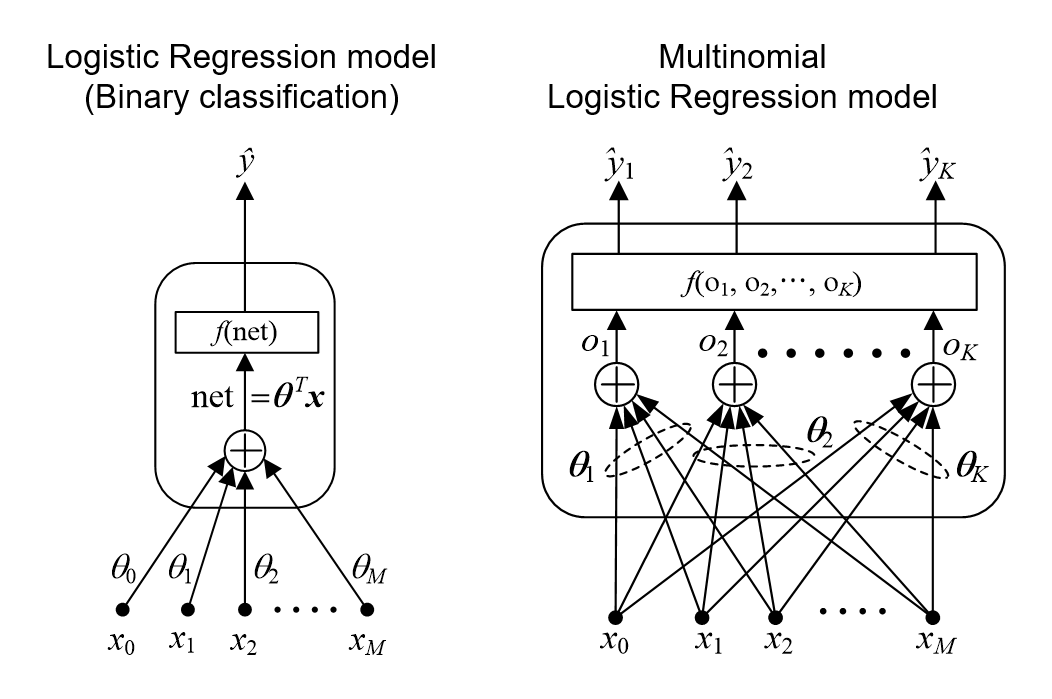  
</div>


## 2. 학습 및 평가 절차 (basic)
    
#### (1) 데이터를 학습데이터와 테스트 데이터로 분리
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

#### (2) 학습 수행(fit)


#### 학습 절차

<div style="display:flex; gap:24px; align-items:flex-start;">
  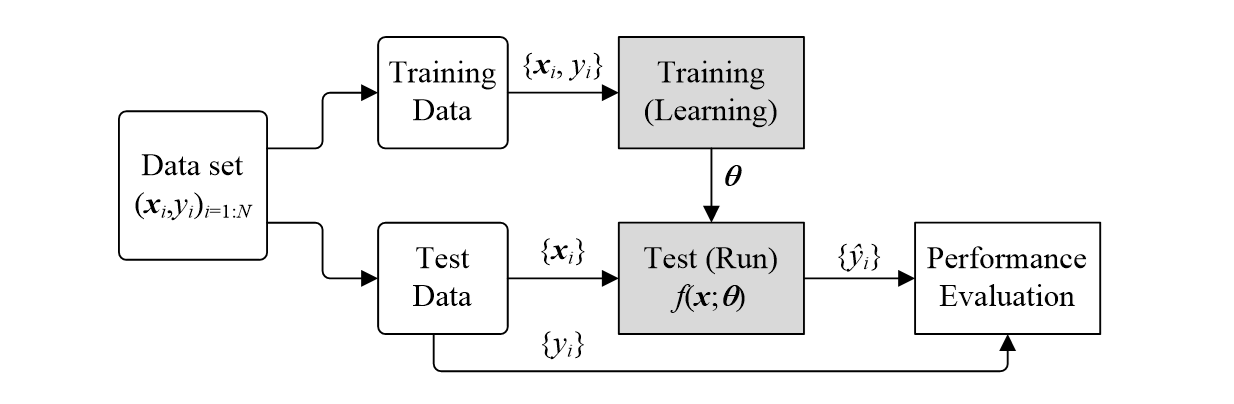
</div>
  

In [ ]:
#########################################################
## (1) Claasification example : Naive implementation

## (1) Divide data for traning (70%) and test (30%)
X_train, X_test, y_train, y_test = mod_sel.train_test_split(X, y, test_size=0.3, random_state=5, stratify = y)

In [ ]:
## (2) Fit model to the data, X_train and y_train
classifier.fit(X_train, y_train)

In [ ]:
classifier.intercept_.shape, classifier.coef_.shape

In [ ]:
classifier.classes_

#### (3) 테스트 수행 (predict)

#### (4) 성능/결과 확인

In [ ]:
## (3) Performance test
y_pred = classifier.predict(X_test)

## (4) Check performance
## For test data
accuracy = 100*sum(y_test==y_pred)/len(y_test)

## For training data
y_pred_train = classifier.predict(X_train)
accuracy_train = 100*sum(y_train==y_pred_train)/len(y_train)

print( "Accuracy(Naive) = %f, %f" % (round(accuracy,2), round(accuracy_train,2)) )

In [ ]:
y_pred[:20], np.array(y_test[:20])

In [ ]:
np.array(y_test)[:20]

#### Checking out probability

In [ ]:
classifier.classes_

In [ ]:
## (6) Get class probability (belief)
y_prob = classifier.predict_proba(X_test)

df_y_prob = pd.DataFrame(y_prob).round(3)
df_y_prob['y_pred'] = y_pred
df_y_prob['y_true'] = list(y_test)
df_y_prob

In [ ]:
b = df_y_prob['y_pred'] != df_y_prob['y_true']
df_y_prob.loc[b,:]

In [ ]:
y_prob.argmax(axis = 1)

In [ ]:
classifier.classes_

 #### 학습을 통해 획득한 최적 파라미터 확인

In [ ]:
print( "theta_0 (intercept) = ", classifier.intercept_ )

In [ ]:
print( "theta[1:M] = " )
print( classifier.coef_ )

## 3. 교차 검증

#### sklearn.model_selection 모듈의 .cross_val_score 사용

#### 교차검증 절차 모식도

<div style="display:flex; gap:24px; align-items:flex-start;">
  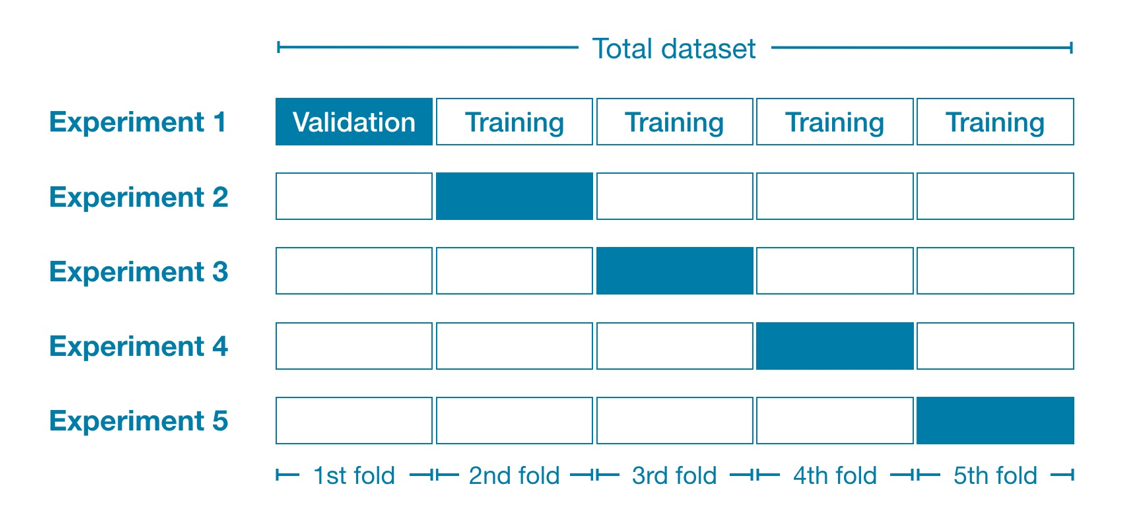  
</div>


## L-fold cross-validation (교차 검증)
1. We divide the entire data (of N samples) into L groups (of N/L samples per group)
2. Select one group for test and use all others for training
3. Measure $J \left( \theta^* ; X_{Test}, y_{test} \right)$ and $J \left( \theta^* ; X_{Train}, y_{train} \right)$
4. Repeat 2 and 3 for each group and take average on both measures!
5. Check if $ J \left( \theta^* ; X_{Test}, y_{test} \right) >> J \left( \theta^* ; X_{Train}, y_{train} \right)$

In [ ]:
#########################################################
## (2) Claasification example: Cross-validation

## Set parameters for cross-validation
NCV = mod_sel.StratifiedKFold(10)

## Performance test
accuracies = mod_sel.cross_val_score(classifier, X, y, scoring='accuracy', cv=NCV, verbose = 2, n_jobs=4)
accuracy = 100*accuracies.mean()
print( "Accuracy(CV) via cross validation = %5.3f" % accuracy )

In [ ]:
accuracies

#### 평가결과의 요약 (혼동 행렬)

In [ ]:
## Confusion matrix & performance report
y_pred = mod_sel.cross_val_predict(classifier, X, y, cv=NCV, verbose = 2, n_jobs=4)

c_mat = met.confusion_matrix(y, y_pred)
print("Confusion Matrix: ")
print(c_mat)
print("Classification Report: ")
print(met.classification_report(np.array(y), y_pred, target_names=label))


#### Only for digits image data

In [ ]:
## Only for digit data
b = y_pred != y
errored_images = digits.images[b,:,:]

In [ ]:
y_pred[b][:10], np.array(y[b][:10])

In [ ]:
## Check images
fig, ax_array = plt.subplots(8, 10)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    ax.imshow(errored_images[i], cmap='gray_r')

plt.setp(axes, xticks=[], yticks=[], frame_on=False)
plt.tight_layout(h_pad=1, w_pad=1)
plt.show()

## 4. ROC and AUC

- Precision (Accuracy)$ = \frac{TP+TN}{TP+TN+FP+FN}$

- Sensitivity (Recall)$ = \frac{TP}{TP+FN} = TPR$

- Specificity$ = \frac{TN}{TN+FP}$

- FPR$ = \frac{FP}{TN+FP}$



<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="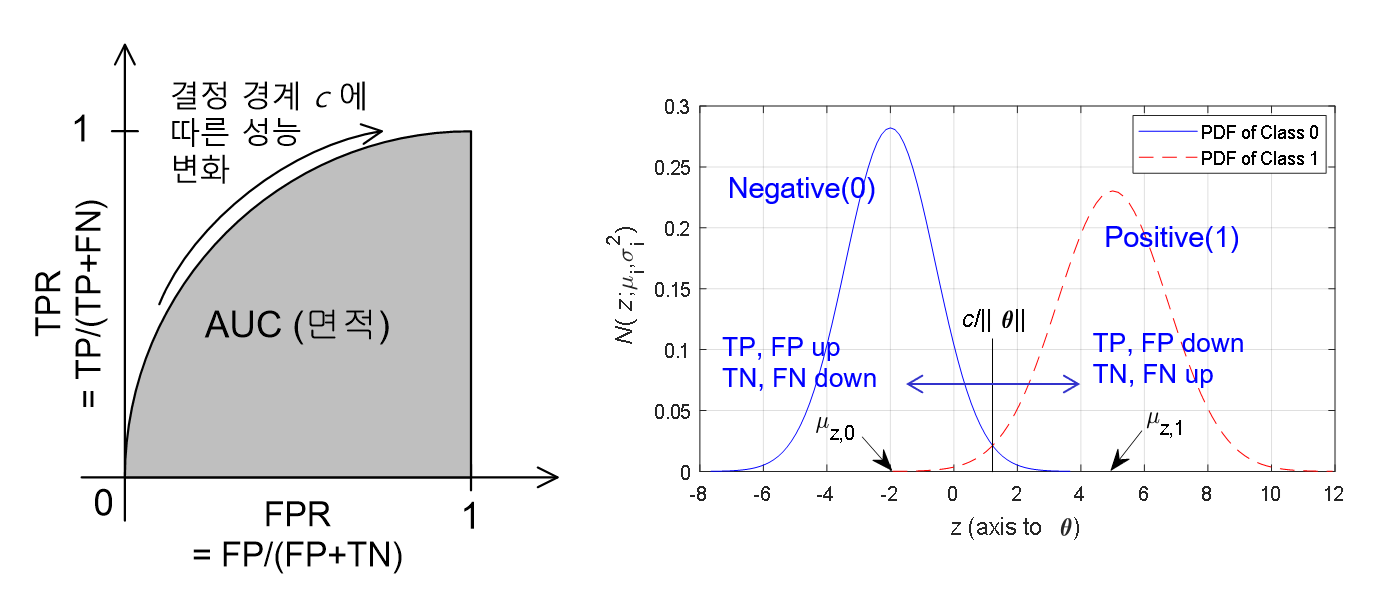
" width="700"/>  
</div>


In [ ]:
## Set parameters for cross-validation
NCV = 5
cv = mod_sel.StratifiedKFold(n_splits=NCV)

y_dec_met = mod_sel.cross_val_predict( classifier, X, y, cv=cv, method = 'decision_function',
                                       verbose = 3, n_jobs = NCV )

In [ ]:
y_dec_met.shape

### Histogram of decision metric (__only for binary classifier__)

In [ ]:
classes = list(set(y))
classes.sort()
classes

In [ ]:
odr = y_dec_met.argsort()
lb = np.quantile(y_dec_met, 0.05) #y_dec_met[odr[int(len(odr)*0.01)]]
ub = np.quantile(y_dec_met, 0.95) #y_dec_met[odr[int(len(odr)*0.99 - 1)]]
display((lb, ub))
b = y == classes[0]
y_dec_met1 = y_dec_met[b]
# y_dec_met1 = np.clip( y_dec_met1, lb, ub )

y_dec_met2 = y_dec_met[~b]
# y_dec_met2 = np.clip( y_dec_met2, lb, ub )

ax = plt.hist(y_dec_met1, bins = 40, alpha = 0.5, density = True)
ax = plt.hist(y_dec_met2, bins = 40, alpha = 0.5, density = True)

#### Compute ROC curve and AUC

In [ ]:
## For both binary and multinomial classifier

# Compute ROC curve and AUC for each class
classifier.fit(X, y)
cls_lst = classifier.classes_

plt.figure(figsize=(5, 5), dpi=100)

if len(cls_lst) == 2:
    i = 1
    target_cls = cls_lst[i]

    b = y == target_cls
    if y_dec_met[b].mean() < 0:
        y_dec_met = -y_dec_met

    fpr, tpr, _ = roc_curve(y.ravel(), y_dec_met.ravel(), pos_label = target_cls)
    roc_auc = auc(fpr, tpr)

    title = "ROC for %s (Area = %0.3f)" % (target_cls, roc_auc)
    plt.plot(fpr, tpr, label=title )
else:
    for i in range(len(cls_lst)):
        t = cls_lst[i]
        fpr, tpr, _ = roc_curve(y, -y_dec_met[:, i], pos_label = t)
        roc_auc = auc(fpr, tpr)

        title = "ROC for %s (Area = %0.3f)" % (t, roc_auc)
        plt.plot(fpr, tpr, label=title ) #, color=clst[i])

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate") #, fontsize = 11)
plt.ylabel("True Positive Rate") #, fontsize = 11)

plt.title("ROC example")
plt.legend(loc="lower right") #, bbox_to_anchor=(1.03, 1)) # , fontsize = 12)
plt.show()


## 5. 그리드 탐색을 이용한 하이퍼 파라미터 최적화

#### (1) 파라미터 그리드 설정

#### (2) sklearn.model_selection 모듈의 .GridSearchCV 사용

#### (3) 베스트 파라미터 추출

#### (4) 베스트 파라미터를 이용한 성능 (재) 평가

In [ ]:
## Set parameters for cross-validation
NCV = 5

## (4) set parameter grid for classifier
param_grid = {'penalty': ['elasticnet'],
             'C': [0.1, 1, 10],
              'l1_ratio': [0, 0.5, 1],
             'solver': ['saga'],
             'max_iter': [2000],
            }

## (5) Search grid to find best parameters
clf = mod_sel.GridSearchCV(classifier, param_grid, cv=NCV, scoring='accuracy', verbose = 2, n_jobs=4)
clf.fit(X,y)

## (6) Get best paramter
best_param = clf.best_params_
print("Best Scroe: " + str(round(clf.best_score_*100,2)) + " with parameters ", end='' )
print(clf.best_params_)


## scikit-learn cool resourses
1. classifier comparison: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py
2. Face recognition: https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html#sphx-glr-auto-examples-applications-plot-face-recognition-py
3. Comparison of solvers: https://scikit-learn.org/stable/auto_examples/linear_model/plot_sgd_comparison.html#sphx-glr-auto-examples-linear-model-plot-sgd-comparison-py
4. MNIST classification: https://scikit-learn.org/stable/auto_examples/linear_model/plot_sparse_logistic_regression_mnist.html#sphx-glr-auto-examples-linear-model-plot-sparse-logistic-regression-mnist-py
5. ROC and AUC: https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_roc_curve_visualization_api.html#sphx-glr-auto-examples-miscellaneous-plot-roc-curve-visualization-api-py
6. ROC and AUC for multinomial classification: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

## Homework

CancerSEEK 데이터를 이용하여 다음의 분류를 수행하여 그 결과를 보고서로 작성하여 제출하라.

1. 암인지 정상인지 판별
2. 암종의 분류

보고서는 다음의 포맷으로 작성하라.

1. 서론 (문제의 설명) - 0.5페이지
2. 실험의 수행 (다양한 결과들을 제시하고 이들에 대한 설명을 제시하라.) - 4페이지
3. 결론 (결과에 대한 코멘트) - 0.5페이지

fontsize = 10
줄간격 = 1줄 (hwp 120%)
페이지 여백: 상하좌우 2cm
용지 A4용지
